In [27]:
import gc
import os
import pickle
import psutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

def ram_gb():
    return psutil.virtual_memory().available / 1e9

print(f"RAM available: {ram_gb():.2f} GB")

# ---- point these at wherever your files actually live ----
DATASETS = [
    {"label": "medium", "accounts_path": r"../data/aml/LI-Medium_accounts.csv", "trans_path": r"../data/aml/LI-Medium_Trans.csv"},
    {"label": "large",  "accounts_path": r"../data/aml/LI-Large_accounts.csv", "trans_path": r"../data/aml/LI-Large_Trans.csv"},
]

ENTITY_TYPES_NEEDED = ["Individual", "Sole Proprietorship"]

RAM available: 1.72 GB


In [28]:
def load_raw_accounts(accounts_path):
    a = pd.read_csv(
        accounts_path,
        dtype={
            "Bank Name": "category",
            "Bank ID": "int32",
            "Account Number": "string",
            "Entity ID": "category",
            "Entity Name": "string",
        },
    )
    a["Entity Type"] = a["Entity Name"].str.extract(r"^([A-Za-z ]+) #").astype("category")
    return a

def prepare_accounts(raw_accounts, source_label):
    a = raw_accounts.copy()
    foreign_pattern = r"^[A-Za-z ]+ Bank #\d+$"
    a["Is_Foreign_Bank"] = a["Bank Name"].str.match(foreign_pattern)
    us_bank_ids = set(a.loc[~a["Is_Foreign_Bank"], "Bank ID"].unique())

    a_us = a[a["Bank ID"].isin(us_bank_ids) & a["Entity Type"].isin(ENTITY_TYPES_NEEDED)].copy()
    a_us["Source_Dataset"] = source_label
    a_us["Account Number Raw"] = a_us["Account Number"]
    a_us["Account Number"] = source_label + "_" + a_us["Account Number Raw"].astype(str)
    a_us["Entity ID"] = source_label + "_" + a_us["Entity ID"].astype(str)
    return a_us, us_bank_ids

accounts_us_parts = []
us_bank_ids_by_source = {}
raw2global_by_source = {}

for ds in DATASETS:
    label = ds["label"]
    raw = load_raw_accounts(ds["accounts_path"])
    a_us, us_bank_ids = prepare_accounts(raw, label)
    accounts_us_parts.append(a_us)
    us_bank_ids_by_source[label] = us_bank_ids
    raw2global_by_source[label] = dict(zip(a_us["Account Number Raw"], a_us["Account Number"]))
    print(f"{label}: {a_us.shape[0]:,} US accounts (Individual/Sole Prop only), {a_us['Entity ID'].nunique():,} entities")

accounts_us = pd.concat(accounts_us_parts, ignore_index=True)
print("\nCombined accounts:", accounts_us.shape)
print(accounts_us.groupby(["Source_Dataset", "Entity Type"], observed=True).size())

acct2entity = dict(zip(accounts_us["Account Number"], accounts_us["Entity ID"]))
acct2etype  = dict(zip(accounts_us["Account Number"], accounts_us["Entity Type"]))

medium: 267,419 US accounts (Individual/Sole Prop only), 93,746 entities
large: 271,380 US accounts (Individual/Sole Prop only), 93,870 entities

Combined accounts: (538799, 9)
Source_Dataset  Entity Type        
large           Individual               1685
                Sole Proprietorship    269695
medium          Individual               1667
                Sole Proprietorship    265752
dtype: int64


In [29]:
CHUNKSIZE = 2_000_000

usecols = ["Timestamp", "From Bank", "Account", "To Bank", "Account.1",
           "Amount Received", "Receiving Currency", "Amount Paid",
           "Payment Currency", "Payment Format", "Is Laundering"]

dtype_map = {
    "From Bank": "int32", "To Bank": "int32",
    "Amount Received": "float32", "Amount Paid": "float32",
    "Receiving Currency": "category", "Payment Currency": "category",
    "Payment Format": "category", "Is Laundering": "int8",
}

# per-entity accumulators (combined across sources, keyed by global entity id)
entity_txn_count = Counter()
entity_received_sum = Counter()

# per-entity-type accumulators (for fitting generation distributions)
sum_log_amount = Counter()      # sum(log(amount)) per entity type, receiver-side only
sumsq_log_amount = Counter()    # sum(log(amount)^2) per entity type
n_amount = Counter()
format_counts_by_type = {t: Counter() for t in ENTITY_TYPES_NEEDED}
hour_counts_by_type = {t: Counter() for t in ENTITY_TYPES_NEEDED}
dow_counts_by_type = {t: Counter() for t in ENTITY_TYPES_NEEDED}
laundering_sum_by_type = Counter()
laundering_n_by_type = Counter()
role_counts_by_type = {t: Counter() for t in ENTITY_TYPES_NEEDED}  # "sender" vs "receiver" split

dataset_span_days = {}  # per source label -> observed day span

for ds in DATASETS:
    label = ds["label"]
    trans_path = ds["trans_path"]
    us_bank_ids = us_bank_ids_by_source[label]
    raw2global = raw2global_by_source[label]

    ts_min_src, ts_max_src = None, None
    n_rows_src = 0

    print(f"\n=== Streaming {label}: {trans_path} ===")
    reader = pd.read_csv(trans_path, usecols=usecols, dtype=dtype_map, chunksize=CHUNKSIZE)

    for i, chunk in enumerate(reader):
        chunk = chunk[chunk["From Bank"].isin(us_bank_ids) & chunk["To Bank"].isin(us_bank_ids)]
        if len(chunk) == 0:
            continue
        n_rows_src += len(chunk)

        ts = pd.to_datetime(chunk["Timestamp"], format="%Y/%m/%d %H:%M")
        ts_min_src = ts.min() if ts_min_src is None else min(ts_min_src, ts.min())
        ts_max_src = ts.max() if ts_max_src is None else max(ts_max_src, ts.max())

        acct_global = chunk["Account"].map(raw2global)
        acct1_global = chunk["Account.1"].map(raw2global)

        sender_entity = acct_global.map(acct2entity)
        receiver_entity = acct1_global.map(acct2entity)
        sender_etype = acct_global.map(acct2etype)
        receiver_etype = acct1_global.map(acct2etype)

        entity_txn_count.update(sender_entity.dropna().value_counts().to_dict())
        entity_txn_count.update(receiver_entity.dropna().value_counts().to_dict())

        recv_amt = chunk["Amount Received"].astype("float64")
        valid_recv = receiver_etype.notna() & (recv_amt > 0)
        if valid_recv.any():
            entity_received_sum.update(
                pd.Series(recv_amt[valid_recv].values, index=receiver_entity[valid_recv].values)
                  .groupby(level=0).sum().to_dict()
            )
            log_amt = np.log(recv_amt[valid_recv])
            grp = receiver_etype[valid_recv]
            sum_log_amount.update(log_amt.groupby(grp, observed=True).sum().to_dict())
            sumsq_log_amount.update((log_amt ** 2).groupby(grp, observed=True).sum().to_dict())
            n_amount.update(grp.value_counts().to_dict())

        # payment format / hour / day-of-week / laundering rate, split by role's entity type
        for etype in ENTITY_TYPES_NEEDED:
            s_mask = sender_etype == etype
            r_mask = receiver_etype == etype
            if s_mask.any():
                format_counts_by_type[etype].update(chunk.loc[s_mask, "Payment Format"].value_counts().to_dict())
                hour_counts_by_type[etype].update(ts[s_mask].dt.hour.value_counts().to_dict())
                dow_counts_by_type[etype].update(ts[s_mask].dt.dayofweek.value_counts().to_dict())
                laundering_sum_by_type[etype] += chunk.loc[s_mask, "Is Laundering"].sum()
                laundering_n_by_type[etype] += s_mask.sum()
                role_counts_by_type[etype]["sender"] += s_mask.sum()
            if r_mask.any():
                role_counts_by_type[etype]["receiver"] += r_mask.sum()

        del chunk, ts, acct_global, acct1_global, sender_entity, receiver_entity, sender_etype, receiver_etype, recv_amt
        if i % 3 == 0:
            gc.collect()
            print(f"  [{label}] {n_rows_src:,} rows so far | RAM {ram_gb():.2f} GB")

    span_days = max((ts_max_src - ts_min_src).days, 1)
    dataset_span_days[label] = span_days
    print(f"  {label} span: {ts_min_src} to {ts_max_src} ({span_days} days) | rows: {n_rows_src:,}")

print("\nDataset spans (days):", dataset_span_days)


=== Streaming medium: ../data/aml/LI-Medium_Trans.csv ===
  [medium] 760,470 rows so far | RAM 0.86 GB
  [medium] 3,014,374 rows so far | RAM 0.88 GB
  [medium] 5,260,629 rows so far | RAM 0.84 GB
  [medium] 7,504,582 rows so far | RAM 0.90 GB
  [medium] 9,755,890 rows so far | RAM 0.94 GB
  [medium] 11,714,457 rows so far | RAM 1.07 GB
  medium span: 2022-09-01 00:00:00 to 2022-09-27 11:52:00 (26 days) | rows: 11,714,457

=== Streaming large: ../data/aml/LI-Large_Trans.csv ===
  [large] 761,149 rows so far | RAM 1.03 GB
  [large] 3,012,776 rows so far | RAM 1.00 GB
  [large] 5,258,190 rows so far | RAM 1.03 GB
  [large] 7,503,577 rows so far | RAM 1.26 GB
  [large] 9,747,825 rows so far | RAM 1.26 GB
  [large] 11,993,491 rows so far | RAM 1.27 GB
  [large] 14,239,534 rows so far | RAM 1.24 GB
  [large] 16,487,797 rows so far | RAM 1.32 GB
  [large] 18,733,579 rows so far | RAM 1.43 GB
  [large] 21,176,895 rows so far | RAM 1.30 GB
  [large] 23,240,036 rows so far | RAM 1.35 GB
  [lar

In [30]:
# ---- build combined per-entity table, with each entity's rate normalized by ITS source's span ----
accts_per_entity = accounts_us.groupby("Entity ID", observed=True)["Account Number"].count()
entity_source_map = accounts_us.drop_duplicates("Entity ID").set_index("Entity ID")["Source_Dataset"]
entity_type_map = accounts_us.drop_duplicates("Entity ID").set_index("Entity ID")["Entity Type"]

df_entity = pd.DataFrame({"n_accounts": accts_per_entity})
df_entity["Entity Type"] = df_entity.index.map(entity_type_map)
df_entity["Source_Dataset"] = df_entity.index.map(entity_source_map)
df_entity["n_transactions"] = df_entity.index.map(entity_txn_count).fillna(0)
df_entity["span_days"] = df_entity["Source_Dataset"].map(dataset_span_days)
df_entity["txn_per_day"] = df_entity["n_transactions"] / df_entity["span_days"]  # normalized rate



In [32]:
# ---- 3.1 Transaction-rate model: txn_per_day ~ intercept + slope * n_accounts, per entity type ----
rate_models = {}
for etype in ENTITY_TYPES_NEEDED:
    sub = df_entity[(df_entity["Entity Type"] == etype) & (df_entity["n_transactions"] > 0)]
    slope, intercept = np.polyfit(sub["n_accounts"], sub["txn_per_day"], 1)
    resid = sub["txn_per_day"] - (intercept + slope * sub["n_accounts"])
    rate_models[etype] = {
        "intercept": float(intercept),
        "slope": float(slope),
        "resid_std": float(resid.std()),
    }
    print(etype, rate_models[etype], "| n entities used to fit:", len(sub))

# ---- 3.2 Amount distribution (log-normal), per entity type ----
amount_models = {}
for etype in ENTITY_TYPES_NEEDED:
    n = n_amount[etype]
    mean_log = sum_log_amount[etype] / n
    var_log = (sumsq_log_amount[etype] / n) - mean_log ** 2
    amount_models[etype] = {"mean_log": mean_log, "std_log": np.sqrt(max(var_log, 1e-6))}
    print(etype, amount_models[etype], "| n amounts:", n)

# ---- 3.3 Payment format distribution, per entity type ----
format_probs_by_type = {
    etype: {k: v / sum(format_counts_by_type[etype].values()) for k, v in format_counts_by_type[etype].items()}
    for etype in ENTITY_TYPES_NEEDED
}

# ---- 3.4 Hour-of-day and day-of-week distributions, per entity type ----
hour_probs_by_type = {
    etype: {k: v / sum(hour_counts_by_type[etype].values()) for k, v in hour_counts_by_type[etype].items()}
    for etype in ENTITY_TYPES_NEEDED
}
dow_probs_by_type = {
    etype: {k: v / sum(dow_counts_by_type[etype].values()) for k, v in dow_counts_by_type[etype].items()}
    for etype in ENTITY_TYPES_NEEDED
}

# ---- 3.5 Laundering rate, per entity type ----
laundering_rate_by_type = {
    etype: laundering_sum_by_type[etype] / laundering_n_by_type[etype]
    for etype in ENTITY_TYPES_NEEDED
}
print("\nLaundering rate by type:", laundering_rate_by_type)

# ---- 3.6 Sender-vs-receiver role split, per entity type (drives realistic income share) ----
role_probs_by_type = {}
for etype in ENTITY_TYPES_NEEDED:
    total = sum(role_counts_by_type[etype].values())
    role_probs_by_type[etype] = {
        "sender": role_counts_by_type[etype]["sender"] / total,
        "receiver": role_counts_by_type[etype]["receiver"] / total,
    }
print("Role split by type:", role_probs_by_type)

Individual {'intercept': 2.2808156227214935, 'slope': 0.3376388969744957, 'resid_std': 3.742560113049856} | n entities used to fit: 286
Sole Proprietorship {'intercept': 2.3200397492773193, 'slope': 0.3106225919336442, 'resid_std': 2.3825806367660074} | n entities used to fit: 186815
Individual {'mean_log': 6.11081214895806, 'std_log': np.float64(3.0564264312099003)} | n amounts: 68802
Sole Proprietorship {'mean_log': 6.915793734391367, 'std_log': np.float64(2.8440617479612436)} | n amounts: 27661917

Laundering rate by type: {'Individual': np.float64(0.00047833157945087533), 'Sole Proprietorship': np.float64(0.00023659736803459595)}
Role split by type: {'Individual': {'sender': np.float64(0.5486203141196384), 'receiver': np.float64(0.4513796858803616)}, 'Sole Proprietorship': {'sender': np.float64(0.4784129693074093), 'receiver': np.float64(0.5215870306925907)}}


In [33]:
# ================================================================
# Part 4 — Generate brand-new synthetic entities + their transactions
#           (no real AML entity is reused; NOT yet assigned to any customer)
# ================================================================

N_ACCOUNTS_RANGE = range(1, 12)     # cover every Num_Bank_Accounts value expected in the credit dataset
N_ENTITIES_PER_BUCKET = 2000         # synthetic entities generated per (n_accounts, entity_type) bucket
SIMULATION_WINDOW_DAYS = 97         # length of the synthetic transaction window per entity

rng = np.random.default_rng(42)

def sample_txn_count(n_accounts, etype):
    m = rate_models[etype]
    mean_rate = max(m["intercept"] + m["slope"] * n_accounts, 0.01)
    noisy_rate = max(rng.normal(mean_rate, m["resid_std"]), 0.01)
    n = int(round(noisy_rate * SIMULATION_WINDOW_DAYS))
    return max(n, 1)

def generate_entity_transactions(entity_id, n_accounts, etype):
    n = sample_txn_count(n_accounts, etype)

    amt_model = amount_models[etype]
    amounts = rng.lognormal(mean=amt_model["mean_log"], sigma=amt_model["std_log"], size=n)

    fmt_names, fmt_p = zip(*format_probs_by_type[etype].items())
    formats = rng.choice(fmt_names, size=n, p=fmt_p)

    days_offset = rng.integers(0, SIMULATION_WINDOW_DAYS, size=n)
    hour_names, hour_p = zip(*hour_probs_by_type[etype].items())
    hours = rng.choice(hour_names, size=n, p=hour_p)
    minutes = rng.integers(0, 60, size=n)
    base_date = pd.Timestamp("2023-01-01")
    timestamps = base_date + pd.to_timedelta(days_offset, unit="D") \
                            + pd.to_timedelta(hours.astype(int), unit="h") \
                            + pd.to_timedelta(minutes, unit="m")

    role_p = role_probs_by_type[etype]
    roles = rng.choice(["sender", "receiver"], size=n, p=[role_p["sender"], role_p["receiver"]])

    is_laundering = rng.choice([0, 1], size=n, p=[1 - laundering_rate_by_type[etype], laundering_rate_by_type[etype]])

    from_bank = abs(hash(entity_id)) % (2**30 - 1)
    account_id = f"SIM_{entity_id}"
    to_banks = rng.integers(0, 2**30 - 1, size=n)
    counterpart_accounts = [f"SIM_EXT_{rng.integers(0, 10**9)}" for _ in range(n)]

    return pd.DataFrame({
        "Timestamp": timestamps,
        "From Bank": from_bank,
        "Account": account_id,
        "To Bank": to_banks,
        "Account.1": counterpart_accounts,
        "Amount Received": np.round(amounts, 2),
        "Receiving Currency": "US Dollar",
        "Amount Paid": np.round(amounts, 2),
        "Payment Currency": "US Dollar",
        "Payment Format": formats,
        "Is Laundering": is_laundering,
        "_role": roles,
    })

synthetic_entity_pool = {}       # (n_accounts, entity_type) -> [synthetic_entity_id, ...]
synthetic_entity_transactions = {}  # synthetic_entity_id -> transactions DataFrame
synthetic_entity_meta = []       # for a summary dataframe

entity_counter = 0
for etype in ENTITY_TYPES_NEEDED:
    for n_acc in N_ACCOUNTS_RANGE:
        ids_this_bucket = []
        for _ in range(N_ENTITIES_PER_BUCKET):
            eid = f"SYN_{etype[:4]}_{n_acc}_{entity_counter}"
            entity_counter += 1
            txns = generate_entity_transactions(eid, n_acc, etype)
            synthetic_entity_transactions[eid] = txns
            ids_this_bucket.append(eid)
            synthetic_entity_meta.append({
                "Entity_ID": eid, "n_accounts": n_acc, "Entity Type": etype,
                "n_transactions": len(txns),
            })
        synthetic_entity_pool[(n_acc, etype)] = ids_this_bucket

synthetic_entity_summary = pd.DataFrame(synthetic_entity_meta)
print(f"Generated {len(synthetic_entity_transactions):,} synthetic entities "
      f"across {len(synthetic_entity_pool)} buckets")
print(synthetic_entity_summary.groupby(["Entity Type", "n_accounts"])["n_transactions"].describe())

Generated 44,000 synthetic entities across 22 buckets
                                 count      mean         std  min     25%  \
Entity Type         n_accounts                                              
Individual          1           2000.0  311.4960  295.618665  1.0   11.00   
                    2           2000.0  325.9975  293.625744  1.0   41.75   
                    3           2000.0  354.3720  294.926707  1.0   85.00   
                    4           2000.0  378.3145  309.496012  1.0  100.75   
                    5           2000.0  417.8610  322.833419  1.0  144.00   
                    6           2000.0  445.7470  326.651068  1.0  179.00   
                    7           2000.0  456.3365  328.189336  1.0  197.00   
                    8           2000.0  496.7960  332.987423  1.0  236.00   
                    9           2000.0  545.8540  336.275556  1.0  293.00   
                    10          2000.0  559.4415  343.671756  1.0  300.00   
                    11

C:\Users\Asus\AppData\Local\Temp\ipykernel_19536\1797101684.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  real_avg = df_entity[df_entity["n_transactions"] > 0].groupby(["Entity Type", "n_accounts"])["txn_per_day"].mean() * SIMULATION_WINDOW_DAYS


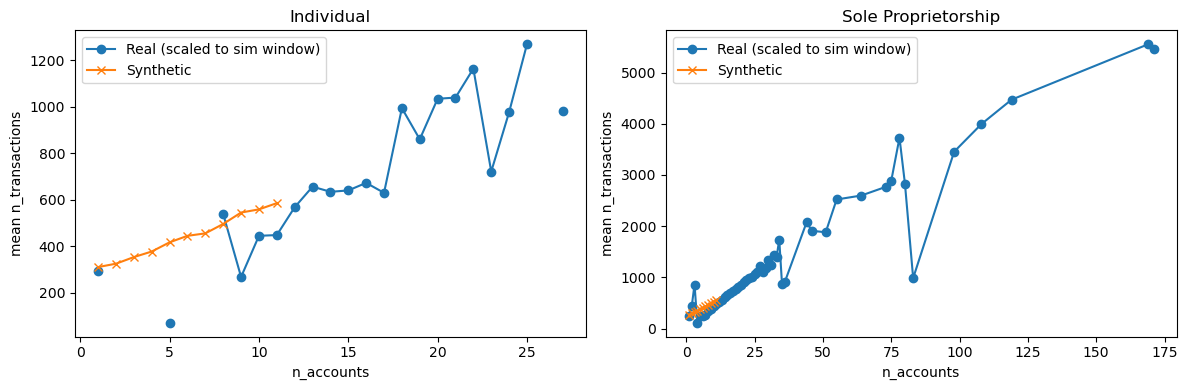


--- Sanity check: random synthetic entities ---
SYN_Sole_2_25115 | type=Sole Proprietorship | n_accounts=2 | n_txns=12 | mean_amount=1034.44 | laundering_rate=0.0000 | receiver_share=0.58
SYN_Indi_9_16589 | type=Individual | n_accounts=9 | n_txns=627 | mean_amount=19148.34 | laundering_rate=0.0000 | receiver_share=0.48
SYN_Sole_5_31775 | type=Sole Proprietorship | n_accounts=5 | n_txns=81 | mean_amount=15950.21 | laundering_rate=0.0000 | receiver_share=0.47
SYN_Indi_11_20636 | type=Individual | n_accounts=11 | n_txns=710 | mean_amount=45532.63 | laundering_rate=0.0000 | receiver_share=0.45
SYN_Sole_7_35290 | type=Sole Proprietorship | n_accounts=7 | n_txns=488 | mean_amount=60660.24 | laundering_rate=0.0000 | receiver_share=0.49
SYN_Sole_9_39072 | type=Sole Proprietorship | n_accounts=9 | n_txns=512 | mean_amount=56735.70 | laundering_rate=0.0000 | receiver_share=0.53

Coverage (entities per n_accounts, per type):
Entity Type  Individual  Sole Proprietorship
n_accounts                

In [34]:
# ---- 5.1 Compare real vs synthetic: mean transactions by n_accounts, per type ----
real_avg = df_entity[df_entity["n_transactions"] > 0].groupby(["Entity Type", "n_accounts"])["txn_per_day"].mean() * SIMULATION_WINDOW_DAYS
synth_avg = synthetic_entity_summary.groupby(["Entity Type", "n_accounts"])["n_transactions"].mean()

fig, axes = plt.subplots(1, len(ENTITY_TYPES_NEEDED), figsize=(12, 4))
for ax, etype in zip(axes, ENTITY_TYPES_NEEDED):
    real_avg.loc[etype].plot(ax=ax, marker="o", label="Real (scaled to sim window)")
    synth_avg.loc[etype].plot(ax=ax, marker="x", label="Synthetic")
    ax.set_title(etype)
    ax.set_xlabel("n_accounts"); ax.set_ylabel("mean n_transactions")
    ax.legend()
plt.tight_layout(); plt.show()

# ---- 5.2 Random spot-check of individual synthetic entities ----
print("\n--- Sanity check: random synthetic entities ---")
sample_eids = rng.choice(list(synthetic_entity_transactions.keys()), size=6, replace=False)
for eid in sample_eids:
    meta = synthetic_entity_summary[synthetic_entity_summary["Entity_ID"] == eid].iloc[0]
    txns = synthetic_entity_transactions[eid]
    print(f"{eid} | type={meta['Entity Type']} | n_accounts={meta['n_accounts']} | "
          f"n_txns={len(txns)} | mean_amount={txns['Amount Received'].mean():.2f} | "
          f"laundering_rate={txns['Is Laundering'].mean():.4f} | "
          f"receiver_share={(txns['_role']=='receiver').mean():.2f}")

# ---- 5.3 Coverage check: confirm every requested n_accounts value has entities for both types ----
coverage = synthetic_entity_summary.groupby(["Entity Type", "n_accounts"])["Entity_ID"].count().unstack("Entity Type")
print("\nCoverage (entities per n_accounts, per type):")
print(coverage)

In [39]:
# ================================================================
# Part 5 — Assign synthetic entities to customers (no entity reused unless
#           its bucket is fully exhausted), build final transaction dataset
#
#           Matching signal: Monthly_Balance vs entity's 30-day net flow
#           (sum(Amount Received) - sum(Amount Paid) in the first 30 days
#            of the entity's simulation window)
# ================================================================

BALANCE_WINDOW_DAYS = 30
BASE_SIM_DATE = pd.Timestamp("2023-01-01")  # matches base_date in generate_entity_transactions


def map_occupation(occ):
    if occ == "Entrepreneur":
        return "Sole Proprietorship"
    elif occ == "Unknown":
        return None
    else:
        return "Individual"


def get_most_frequent(series):
    mode_vals = series.mode()
    if not mode_vals.empty:
        return mode_vals.iloc[0]
    return "Unknown"


def build_customer_profile(raw_df):
    has_balance = "Monthly_Balance" in raw_df.columns

    agg_cols = ["Occupation", "Num_Bank_Accounts"]
    if has_balance:
        agg_cols.append("Monthly_Balance")

    profile = raw_df.groupby("Customer_ID")[agg_cols].agg(get_most_frequent).reset_index()
    if not has_balance:
        profile["Monthly_Balance"] = np.nan

    profile["Num_Bank_Accounts"] = profile["Num_Bank_Accounts"].round().astype(int)
    profile["Assumed_Entity_Type"] = profile["Occupation"].apply(map_occupation)

    # Unknown -> sample between Individual / Sole Proprietorship, proportional to synthetic entity counts
    etype_counts = pd.Series({t: len(synthetic_entity_summary[synthetic_entity_summary["Entity Type"] == t])
                               for t in ENTITY_TYPES_NEEDED})
    entity_type_probs = etype_counts / etype_counts.sum()

    rng_unknown = np.random.default_rng(11)
    mask = profile["Assumed_Entity_Type"].isna()
    profile.loc[mask, "Assumed_Entity_Type"] = rng_unknown.choice(
        entity_type_probs.index, size=mask.sum(), p=entity_type_probs.values
    )
    return profile


# ---- 5.1 30-day net-flow lookup for synthetic entities (proxy for Monthly_Balance) ----
def build_synthetic_balance_lookup(synthetic_entity_transactions,
                                    window_days=BALANCE_WINDOW_DAYS,
                                    base_date=BASE_SIM_DATE):
    window_end = base_date + pd.Timedelta(days=window_days)
    records = []
    for eid, txns in synthetic_entity_transactions.items():
        w = txns[(txns["Timestamp"] >= base_date) & (txns["Timestamp"] < window_end)]
        received_30d = w.loc[w["_role"] == "receiver", "Amount Received"].sum()
        sent_30d = w.loc[w["_role"] == "sender", "Amount Paid"].sum()
        net_flow_30d = received_30d - sent_30d
        records.append((eid, received_30d, sent_30d, net_flow_30d))
    return pd.DataFrame(
        records,
        columns=["Entity_ID", "Received_30d", "Sent_30d", "Net_Flow_30d"]
    ).set_index("Entity_ID")


entity_balance_lookup = build_synthetic_balance_lookup(synthetic_entity_transactions)
print("Synthetic entity 30-day net-flow lookup:")
print(entity_balance_lookup.describe())


# ---- 5.2 Bucket lookups for nearest-n_accounts fallback ----
avail_by_type = {}
for (n_acc, etype) in synthetic_entity_pool:
    avail_by_type.setdefault(etype, []).append(n_acc)


def nearest_n_accounts(n_acc, etype):
    opts = avail_by_type.get(etype, [])
    return min(opts, key=lambda x: abs(x - n_acc)) if opts else None


# ---- 5.3 Assignment: Monthly_Balance matched where possible, NO reuse until a bucket is exhausted ----
def assign_synthetic_entities(profile, synthetic_entity_pool, entity_balance_lookup, avail_by_type, seed=2024):
    rng = np.random.default_rng(seed)
    assigned = []
    used_per_bucket = {}      # bucket_key -> set of already-assigned entity ids
    reuse_count = 0

    for row in profile.itertuples(index=False):
        key = (row.Num_Bank_Accounts, row.Assumed_Entity_Type)
        if key not in synthetic_entity_pool:
            matched_n = nearest_n_accounts(row.Num_Bank_Accounts, row.Assumed_Entity_Type)
            key = (matched_n, row.Assumed_Entity_Type)

        candidates = synthetic_entity_pool.get(key, [])
        if not candidates:
            assigned.append(None)
            continue

        used = used_per_bucket.setdefault(key, set())
        available = [c for c in candidates if c not in used]

        if not available:
            # bucket fully exhausted: every synthetic entity in it already assigned once ->
            # allow reuse as a last resort, but track how often this happens
            available = candidates
            reuse_count += 1

        target_balance = row.Monthly_Balance
        if pd.notna(target_balance):
            cand_net_flow = entity_balance_lookup.reindex(available)["Net_Flow_30d"]
            balance_diff = (cand_net_flow - target_balance).abs()
            best_eid = balance_diff.idxmin()
        else:
            best_eid = rng.choice(available)

        used.add(best_eid)
        assigned.append(best_eid)

    print(f"  Entities reused due to bucket exhaustion: {reuse_count:,} / {len(profile):,} customers")
    return assigned


# ---- 5.4 Copy an assigned synthetic entity's transactions onto its customer ----
def build_customer_transactions(profile, synthetic_entity_transactions):
    frames = []
    for row in profile.itertuples(index=False):
        eid = row.Assigned_Entity_ID
        if eid is None or eid not in synthetic_entity_transactions:
            continue
        txns = synthetic_entity_transactions[eid].copy()
        txns["Customer_ID"] = row.Customer_ID
        txns["Source_Entity_ID"] = eid
        txns["Assumed_Entity_Type"] = row.Assumed_Entity_Type
        frames.append(txns)
    return pd.concat(frames, ignore_index=True)


# ---- 5.5 30-day net-flow estimate from the customer's realized (synthetic) transactions ----
def estimate_balance(cust_txn_df, balance_window_days=BALANCE_WINDOW_DAYS, base_date=BASE_SIM_DATE):
    window_end = base_date + pd.Timedelta(days=balance_window_days)

    def agg(g):
        n = len(g)
        w = g[(g["Timestamp"] >= base_date) & (g["Timestamp"] < window_end)]
        received_30d = w.loc[w["_role"] == "receiver", "Amount Received"].sum()
        sent_30d = w.loc[w["_role"] == "sender", "Amount Paid"].sum()
        return pd.Series({
            "N_Transactions": n,
            "Received_30d": received_30d,
            "Sent_30d": sent_30d,
            "Estimated_Monthly_Balance": received_30d - sent_30d,
        })

    return cust_txn_df.groupby("Customer_ID").apply(agg).reset_index()


# ---- 5.6 Full pipeline for one split ----
def process_split(raw_df, synthetic_entity_pool, entity_balance_lookup, avail_by_type,
                   synthetic_entity_transactions, seed=2024):
    profile = build_customer_profile(raw_df)
    profile["Assigned_Entity_ID"] = assign_synthetic_entities(
        profile, synthetic_entity_pool, entity_balance_lookup, avail_by_type, seed
    )
    print(f"  {profile['Assigned_Entity_ID'].isna().sum()} customers had no matching bucket")

    txns = build_customer_transactions(profile, synthetic_entity_transactions)
    balance_df = estimate_balance(txns)
    profile = profile.merge(balance_df, on="Customer_ID", how="left")
    return profile, txns


# ---- 5.7 Run on train ----
train_df = pd.read_csv("../data/cleaned_credit/cleaned_train.csv", low_memory=False)
print("Processing train split...")
customer_profile, customer_transactions = process_split(
    train_df, synthetic_entity_pool, entity_balance_lookup, avail_by_type,
    synthetic_entity_transactions, seed=2024
)
customer_profile.to_csv("../data/simulated/customer_profile_train.csv", index=False)
customer_transactions.to_csv("../data/simulated/customer_transactions_train.csv", index=False)
print(customer_profile.shape, customer_transactions.shape)

# ---- 5.8 Run on test ----
test_df = pd.read_csv("../data/cleaned_credit/cleaned_test.csv", low_memory=False)
print("\nProcessing test split...")
test_profile, test_transactions = process_split(
    test_df, synthetic_entity_pool, entity_balance_lookup, avail_by_type,
    synthetic_entity_transactions, seed=4242
)
test_profile.to_csv("../data/simulated/customer_profile_test.csv", index=False)
test_transactions.to_csv("../data/simulated/customer_transactions_test.csv", index=False)
print(test_profile.shape, test_transactions.shape)

Synthetic entity 30-day net-flow lookup:
       Received_30d      Sent_30d  Net_Flow_30d
count  4.400000e+04  4.400000e+04  4.400000e+04
mean   3.270236e+06  3.551499e+06 -2.812628e+05
std    1.294154e+07  2.046171e+07  2.399715e+07
min    0.000000e+00  0.000000e+00 -2.714318e+09
25%    3.913910e+05  4.255313e+05 -1.091979e+06
50%    1.316851e+06  1.389935e+06  0.000000e+00
75%    3.116963e+06  3.220718e+06  9.096020e+05
max    1.658915e+09  2.717319e+09  1.656452e+09
Processing train split...
  Entities reused due to bucket exhaustion: 0 / 12,500 customers
  0 customers had no matching bucket


C:\Users\Asus\AppData\Local\Temp\ipykernel_19536\2064982392.py:164: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return cust_txn_df.groupby("Customer_ID").apply(agg).reset_index()


(12500, 10) (3740540, 15)

Processing test split...
  Entities reused due to bucket exhaustion: 0 / 12,500 customers
  0 customers had no matching bucket


C:\Users\Asus\AppData\Local\Temp\ipykernel_19536\2064982392.py:164: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return cust_txn_df.groupby("Customer_ID").apply(agg).reset_index()


(12500, 10) (3730720, 15)


In [40]:
# ---- Uniqueness check: confirm no two customers share the same entity (unless bucket exhausted) ----
def check_uniqueness(profile, label="train"):
    print(f"\n================ UNIQUENESS CHECK: {label} split ================")
    valid = profile.dropna(subset=["Assigned_Entity_ID"])
    n_customers = len(valid)
    n_unique_entities = valid["Assigned_Entity_ID"].nunique()
    dup_counts = valid["Assigned_Entity_ID"].value_counts()
    n_shared = (dup_counts > 1).sum()
    print(f"Customers assigned: {n_customers:,} | Unique entities used: {n_unique_entities:,}")
    print(f"Entities shared by >1 customer: {n_shared:,} (0 expected unless a bucket was exhausted)")
    if n_shared > 0:
        print("Most-reused entities:")
        print(dup_counts[dup_counts > 1].head(10))

check_uniqueness(customer_profile, label="train")
check_uniqueness(test_profile, label="test")


# ---- Random spot-check: occupation/type match, transaction counts, balance comparison ----
def sanity_check_assignments(profile, synthetic_entity_transactions, entity_balance_lookup,
                              n_samples=8, seed=99, label="train"):
    print(f"\n================ SANITY CHECK: {label} split ================")
    valid = profile.dropna(subset=["Assigned_Entity_ID"])
    sample = valid.sample(n=min(n_samples, len(valid)), random_state=seed)

    for row in sample.itertuples(index=False):
        eid = row.Assigned_Entity_ID
        meta = synthetic_entity_summary[synthetic_entity_summary["Entity_ID"] == eid].iloc[0]
        n_entity_txns = len(synthetic_entity_transactions.get(eid, []))

        print(f"\nCustomer {row.Customer_ID}")
        print(f"  Occupation                 : {row.Occupation}")
        print(f"  Assumed_Entity_Type         : {row.Assumed_Entity_Type}")
        print(f"  Num_Bank_Accounts (customer): {row.Num_Bank_Accounts}")
        print(f"  Assigned synthetic entity   : {eid}")
        print(f"  Entity's Entity Type        : {meta['Entity Type']}  "
              f"({'MATCH' if meta['Entity Type'] == row.Assumed_Entity_Type else 'MISMATCH'})")
        print(f"  Entity's n_accounts         : {meta['n_accounts']}")
        print(f"  N_Transactions (customer)   : {getattr(row, 'N_Transactions', 'N/A')}")
        print(f"  N_Transactions (entity)     : {n_entity_txns}")
        print(f"  Customer Monthly_Balance    : {row.Monthly_Balance}")
        print(f"  Customer Estimated_Monthly_Balance (30d net flow): {getattr(row, 'Estimated_Monthly_Balance', np.nan)}")
        if eid in entity_balance_lookup.index:
            print(f"  Entity's own Net_Flow_30d   : {entity_balance_lookup.loc[eid, 'Net_Flow_30d']:.2f}")

sanity_check_assignments(customer_profile, synthetic_entity_transactions, entity_balance_lookup, label="train")
sanity_check_assignments(test_profile, synthetic_entity_transactions, entity_balance_lookup, label="test")


# ---- Aggregate check: entity-type match rate + balance error ----
def sanity_check_aggregate(profile, label="train"):
    print(f"\n================ AGGREGATE CHECK: {label} split ================")
    valid = profile.dropna(subset=["Assigned_Entity_ID"]).copy()
    entity_type_map = synthetic_entity_summary.set_index("Entity_ID")["Entity Type"]
    valid["Entity_True_Type"] = valid["Assigned_Entity_ID"].map(entity_type_map)
    match_rate = (valid["Entity_True_Type"] == valid["Assumed_Entity_Type"]).mean()
    print(f"Entity-type match rate: {match_rate:.2%}")

    has_balance = valid["Monthly_Balance"].notna()
    if has_balance.any():
        bal_err = (valid.loc[has_balance, "Estimated_Monthly_Balance"] - valid.loc[has_balance, "Monthly_Balance"]).abs()
        # relative error is unstable near zero balances, so also report a robust version with a clipped denominator
        denom = valid.loc[has_balance, "Monthly_Balance"].abs().clip(lower=1.0)
        bal_rel_err = bal_err / denom
        print(f"Balance-matched customers: {has_balance.sum():,}")
        print(f"Median absolute balance (30d net flow) error: {bal_err.median():,.2f}")
        print(f"Median relative balance error (clipped denom): {bal_rel_err.median():.2%}")
    else:
        print("No usable Monthly_Balance for balance-matching.")

sanity_check_aggregate(customer_profile, label="train")
sanity_check_aggregate(test_profile, label="test")


================ UNIQUENESS CHECK: train split ================
Customers assigned: 12,500 | Unique entities used: 12,500
Entities shared by >1 customer: 0 (0 expected unless a bucket was exhausted)

================ UNIQUENESS CHECK: test split ================
Customers assigned: 12,500 | Unique entities used: 12,500
Entities shared by >1 customer: 0 (0 expected unless a bucket was exhausted)

================ SANITY CHECK: train split ================

Customer CUS_0x7d41
  Occupation                 : Doctor
  Assumed_Entity_Type         : Individual
  Num_Bank_Accounts (customer): 7
  Assigned synthetic entity   : SYN_Indi_7_12899
  Entity's Entity Type        : Individual  (MATCH)
  Entity's n_accounts         : 7
  N_Transactions (customer)   : 236.0
  N_Transactions (entity)     : 236
  Customer Monthly_Balance    : 271.2785278784429
  Customer Estimated_Monthly_Balance (30d net flow): 593409.2399999999
  Entity's own Net_Flow_30d   : 593409.24

Customer CUS_0x5856
  Occupatio